In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc

file_path = '../data/TROPOMI_2018_data'
emissions_path = '../data/coco2_ps_catalogue_v2.0.csv'

# Read the emissions data
emissions = pd.read_csv(emissions_path)
# Filter emissions data for the specified date




In [7]:
emissions[:6000]

,ID,ISO3,fuel,longitude,latitude,co2_emis_ty,nox_emis_ty,sox_emis_ty,co_emis_ty,ch4_emis_ty,ID_MonthFact,ID_WeekFact,ID_HourFact,ID_VertProf,cumulative_NOx_sum,cumulative_CO2_sum,NOx_percentage,CO2_percentage
0,CoCO2_10706,RUS,natural gas,73.488900,61.279400,2.563959e+07,44548.165635,1283.673460,11549.626854,457.033662,FM_336,FW_275,FH_260,VP_09598,4.454817e+04,2.563959e+07,0.002733,0.001898
1,CoCO2_15522,POL,coal,19.326467,51.265983,3.840000e+07,30100.000000,45100.000000,26300.000000,99.999000,FM_139,FW_104,FH_095,VP_07680,7.464817e+04,6.403959e+07,0.004579,0.004740
2,CoCO2_11814,USA,coal,-78.675759,41.491466,6.542279e+05,29651.599383,0.000000,7229.197083,1.856072,FM_267,FW_222,FH_210,VP_02695,1.042998e+05,6.469382e+07,0.006398,0.004788
3,CoCO2_10698,RUS,natural gas,37.687900,55.916200,1.645677e+07,28593.238856,823.925774,7413.127670,293.347043,FM_336,FW_275,FH_260,VP_01932,1.328930e+05,8.115059e+07,0.008152,0.006006
4,CoCO2_10835,SAU,oil,39.555858,20.627494,1.271810e+07,28471.290029,87519.805057,4957.941986,508.044048,FM_353,FW_286,FH_271,VP_09123,1.613643e+05,9.386869e+07,0.009898,0.006948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,CoCO2_03574,CHN,coal,98.308946,39.793798,5.847267e+05,656.566741,448.702435,63.583078,6.181043,FM_040,FW_281,FH_266,VP_05179,1.470003e+07,1.141389e+10,0.901719,0.844780
5996,CoCO2_03573,CHN,coal,98.308946,39.793798,5.847267e+05,656.566741,448.702435,63.583078,6.181043,FM_040,FW_281,FH_266,VP_05179,1.470069e+07,1.141447e+10,0.901760,0.844823
5997,CoCO2_04071,CHN,coal,110.166504,38.736586,5.847267e+05,656.566741,448.702435,63.583078,6.181043,FM_040,FW_281,FH_266,VP_08873,1.470135e+07,1.141505e+10,0.901800,0.844866
5998,CoCO2_04316,CHN,coal,126.503770,43.908481,5.847267e+05,656.566741,448.702435,63.583078,6.181043,FM_040,FW_281,FH_266,VP_09311,1.470200e+07,1.141564e+10,0.901840,0.844910


In [14]:
file_name = 'S5P_RPRO_L2__NO2____20180620T230521_20180621T004650_03555_03_020400_20221129T185109.nc'
file_path = '../data/TROPOMI_2018_data'
file = os.path.join(file_path, file_name)

# Read the netCDF file
with nc.Dataset(file) as dataset:
    # Extract latitude and longitude
    longitude = dataset['PRODUCT/longitude'][:]
    latitude = dataset['PRODUCT/latitude'][:]
    no2 = dataset['PRODUCT/nitrogendioxide_tropospheric_column'][:]
    wind_u = dataset['PRODUCT/SUPPORT_DATA/INPUT_DATA/eastward_wind'][:]
    wind_v = dataset['PRODUCT/SUPPORT_DATA/INPUT_DATA/northward_wind'][:]
    utc_time = dataset['PRODUCT/time_utc'][:]

In [ ]:
import os
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree
from datetime import datetime, timedelta
import time
import multiprocessing as mp
from functools import partial
import logging
from scipy.ndimage import gaussian_filter
from pyproj import Geod

def label_no2_plume(no2_data, lon, lat, lon_left, lon_right, lat_top, lat_bot, v_x, v_y, plant_lon, plant_lat,
                    threshold_factor=4.5, threshold=1e-5, max_distance_km=20,
                    close_distance_km=8, max_angle_diff=30, flagged_area=10.0, sigma=100):
    geod = Geod(ellps='WGS84')
    tol = 1e-12
    mask = (np.abs(no2_data) > tol).astype(float)
    weighted = gaussian_filter(no2_data * mask, sigma=sigma)
    norm = gaussian_filter(mask, sigma=sigma)
    background_2d = np.divide(weighted, norm, out=np.zeros_like(weighted), where=norm != 0)
    anomalies_2d = no2_data - background_2d
    anomalies_2d[mask == 0] = np.nan
    h, w = no2_data.shape

    lon, lat = lon.ravel(), lat.ravel()
    anomalies_flat = anomalies_2d.ravel()
    valid = np.isfinite(anomalies_flat)
    lon, lat, vals = lon[valid], lat[valid], anomalies_flat[valid]

    fwd_az, _, dist_m = geod.inv(np.full_like(lon, plant_lon),
                                 np.full_like(lat, plant_lat), lon, lat)
    bearings = fwd_az % 360
    dist_km = dist_m / 1000.0

    within_50km = dist_km <= 50
    anomalies_50 = vals[within_50km]
    if len(anomalies_50) > 0:
        median_anom = np.ma.median(anomalies_50)
        mad = np.ma.median(np.abs(anomalies_50 - median_anom)) or np.std(anomalies_50)
    else:
        median_anom, mad = 0, 0
    thresh_new = max(median_anom + threshold_factor * mad, threshold)

    wind_dir_deg = (np.degrees(np.arctan2(v_x, v_y)) % 360)
    bearing_diff = np.abs((bearings - wind_dir_deg + 180) % 360 - 180)
    plume_mask_1d = (((dist_km <= max_distance_km) & (vals > thresh_new) & (bearing_diff <= max_angle_diff))
                     | ((dist_km <= close_distance_km) & (vals > thresh_new)))
    plume_mask_2d = np.zeros((h, w), dtype=bool)
    plume_mask_2d.ravel()[valid] = plume_mask_1d    # Compute vectorized cell area using a spherical approximation:
    
    # For each cell, use its four vertices:
    #   Top-left:     (lat_b[i, j],   lon_b[i, j])
    #   Top-right:    (lat_b[i, j+1], lon_b[i, j+1])
    #   Bottom-right: (lat_b[i+1, j+1], lon_b[i+1, j+1])
    #   Bottom-left:  (lat_b[i+1, j], lon_b[i+1, j])
    # For a cell bounded by constant lat and lon boundaries, a good approximation is:
    #   area = R² * |(lon_right - lon_left) in radians| * |sin(lat_top in radians) - sin(lat_bottom in radians)|
    R = 6371000.0  # Earth radius in meters

    # Convert differences to radians and compute the cell area (vectorized)
    dlon_rad = np.radians(lon_right - lon_left)
    cell_areas = R**2 * np.abs(dlon_rad) * np.abs(np.sin(np.radians(lat_top)) - np.sin(np.radians(lat_bot)))

    # Sum only the areas of flagged (plume) pixels
    total_area_m2 = np.sum(cell_areas[plume_mask_2d])
    plume_area_km2 = total_area_m2 / 1e6  # Convert m² to km²

    return (plume_area_km2 >= flagged_area)

In [9]:
import pandas as pd

df = pd.read_csv('../data/valid_tropomi_emissions_6000.csv')
row = df.iloc[0]

file_path = row['file_path']
plant_lat = row['latitude']
plant_lon = row['longitude']
utc_time = row['utc_time']
wind_u = row['wind_u']
wind_v = row['wind_v']

with nc.Dataset(file_path) as ds:
    lats = ds['PRODUCT/latitude'][:][0]
    lons = ds['PRODUCT/longitude'][:][0]
    no2 = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:][0]

# Assume lat, lon, and plume_mask_2d are 2D arrays of shape (M, N)
M, N = lats.shape
geod = Geod(ellps='WGS84')
M, N = lats.shape  # lats and lons are (M, N) arrays

# Create boundary arrays of shape (M+1, N+1)
lat_b = np.empty((M+1, N+1))
lon_b = np.empty((M+1, N+1))

# Interior boundaries: average of the four surrounding centers
lat_b[1:M, 1:N] = (lats[:-1, :-1] + lats[:-1, 1:] + lats[1:, :-1] + lats[1:, 1:]) / 4
lon_b[1:M, 1:N] = (lons[:-1, :-1] + lons[:-1, 1:] + lons[1:, :-1] + lons[1:, 1:]) / 4

# Extrapolate edges using mirror logic (fixing indexing)
lat_b[0, 1:N]    = 2 * lats[0, 1:N]   - lat_b[1, 1:N]
lat_b[M, 1:N]    = 2 * lats[-1, 1:N]  - lat_b[M-1, 1:N]
lat_b[1:M, 0]    = 2 * lats[1:M, 0]   - lat_b[1:M, 1]
lat_b[1:M, N]    = 2 * lats[1:M, -1]  - lat_b[1:M, N-1]
lat_b[0,0]       = 2 * lats[0,0]      - lat_b[1,1]
lat_b[0,N]       = 2 * lats[0,-1]     - lat_b[1,N-1]
lat_b[M,0]       = 2 * lats[-1,0]     - lat_b[M-1,1]
lat_b[M,N]       = 2 * lats[-1,-1]    - lat_b[M-1,N-1]

lon_b[0, 1:N]    = 2 * lons[0, 1:N]   - lon_b[1, 1:N]
lon_b[M, 1:N]    = 2 * lons[-1, 1:N]  - lon_b[M-1, 1:N]
lon_b[1:M, 0]    = 2 * lons[1:M, 0]   - lon_b[1:M, 1]
lon_b[1:M, N]    = 2 * lons[1:M, -1]  - lon_b[1:M, N-1]
lon_b[0,0]       = 2 * lons[0,0]      - lon_b[1,1]
lon_b[0,N]       = 2 * lons[0,-1]     - lon_b[1,N-1]
lon_b[M,0]       = 2 * lons[-1,0]     - lon_b[M-1,1]
lon_b[M,N]       = 2 * lons[-1,-1]    - lon_b[M-1,N-1]

# Compute cell areas using a spherical approximation
# For each cell, use left/right boundaries from lon_b and top/bottom from lat_b
lon_left  = lon_b[:-1, :-1]
lon_right = lon_b[:-1, 1:]
lat_top   = lat_b[:-1, :-1]
lat_bot   = lat_b[1:, :-1]


# Use the left/right boundaries from lon_b and top/bottom boundaries from lat_b:
lon_left  = lon_b[:-1, :-1]
lon_right = lon_b[:-1, 1:]
lat_top   = lat_b[:-1, :-1]
lat_bot   = lat_b[1:, :-1]

plume_label = label_no2_plume(no2, lons, lats, lon_left, lon_right, lat_top, lat_bot, wind_u, wind_v, plant_lon, plant_lat,
                    threshold_factor=4.5, threshold=1e-5, max_distance_km=20,
                    close_distance_km=8, max_angle_diff=30, flagged_area=10.0, sigma=100)


/tmp/ipykernel_3050504/487384083.py:3: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/valid_tropomi_emissions_6000.csv')


In [ ]:

import os
import numpy as np
import pandas as pd
import netCDF4 as nc
from sklearn.neighbors import BallTree
from datetime import datetime, timedelta
import time
import multiprocessing as mp
from functools import partial
import logging
from scipy.ndimage import gaussian_filter
from pyproj import Geod
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Circle
import cartopy.crs as ccrs
plt.rcdefaults()

def label_no2_plume(no2_data, lon, lat, lon_left, lon_right, lat_top, lat_bot, v_x, v_y, plant_lon, plant_lat,
                    threshold_factor=4.5, threshold=1e-5, max_distance_km=20,
                    close_distance_km=8, max_angle_diff=30, flagged_area=10.0, sigma=100):
    """
    Label NO2 plumes based on anomaly detection and wind direction.
    Returns the plume mask and intermediate data for visualization.
    """
    geod = Geod(ellps='WGS84')
    tol = 1e-12
    mask = (np.abs(no2_data) > tol).astype(float)
    weighted = gaussian_filter(no2_data * mask, sigma=sigma)
    norm = gaussian_filter(mask, sigma=sigma)
    background_2d = np.divide(weighted, norm, out=np.zeros_like(weighted), where=norm != 0)
    anomalies_2d = no2_data - background_2d
    anomalies_2d[mask == 0] = np.nan
    h, w = no2_data.shape

    lon_2d, lat_2d = lon, lat  # Keep original 2D arrays
    lon, lat = lon.ravel(), lat.ravel()
    anomalies_flat = anomalies_2d.ravel()
    valid = np.isfinite(anomalies_flat)
    lon_valid, lat_valid, vals = lon[valid], lat[valid], anomalies_flat[valid]

    # Calculate distance and bearing from power plant to each valid point
    fwd_az, _, dist_m = geod.inv(np.full_like(lon_valid, plant_lon),
                                 np.full_like(lat_valid, plant_lat), lon_valid, lat_valid)
    bearings = fwd_az % 360
    dist_km = dist_m / 1000.0

    # Calculate threshold based on median absolute deviation
    within_50km = dist_km <= 50
    anomalies_50 = vals[within_50km]
    if len(anomalies_50) > 0:
        median_anom = np.ma.median(anomalies_50)
        mad = np.ma.median(np.abs(anomalies_50 - median_anom)) or np.std(anomalies_50)
    else:
        median_anom, mad = 0, 0
    thresh_new = max(median_anom + threshold_factor * mad, threshold)

    # Calculate wind direction and bearing difference
    wind_dir_deg = (np.degrees(np.arctan2(v_x, v_y)) % 360)
    bearing_diff = np.abs((bearings - wind_dir_deg + 180) % 360 - 180)
    
    # Create plume mask based on thresholds and bearing difference
    plume_mask_1d = (((dist_km <= max_distance_km) & (vals > thresh_new) & (bearing_diff <= max_angle_diff))
                     | ((dist_km <= close_distance_km) & (vals > thresh_new)))
    plume_mask_2d = np.zeros((h, w), dtype=bool)
    plume_mask_2d.ravel()[valid] = plume_mask_1d
    
    # Calculate plume area
    R = 6371000.0  # Earth radius in meters
    dlon_rad = np.radians(lon_right - lon_left)
    cell_areas = R**2 * np.abs(dlon_rad) * np.abs(np.sin(np.radians(lat_top)) - np.sin(np.radians(lat_bot)))
    total_area_m2 = np.sum(cell_areas[plume_mask_2d])
    plume_area_km2 = total_area_m2 / 1e6  # Convert m² to km²
    
    # Determine if plume is significant based on area
    is_significant_plume = (plume_area_km2 >= flagged_area)
    
    # Return all intermediate results for visualization
    return {
        'is_significant': is_significant_plume,
        'plume_mask': plume_mask_2d,
        'background': background_2d,
        'anomalies': anomalies_2d,
        'threshold': thresh_new,
        'plume_area_km2': plume_area_km2,
        'wind_dir_deg': wind_dir_deg
    }

def visualize_plume_detection(file_path, plant_lat, plant_lon, wind_u, wind_v, 
                              threshold_factor=4.5, threshold=1e-5,
                              max_distance_km=20, close_distance_km=8, 
                              max_angle_diff=30, flagged_area=10.0, sigma=100):
    """
    Create a comprehensive visualization of the plume detection process
    """
    # Load NO2 data from netCDF file
    with nc.Dataset(file_path) as ds:
        lats = ds['PRODUCT/latitude'][:][0]
        lons = ds['PRODUCT/longitude'][:][0]
        no2_masked = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:][0]
        no2 = np.array(np.ma.filled(no2_masked, np.nan))
        # Extract metadata if available
        try:
            facility_name = os.path.basename(file_path).split('_')[0]
            datetime_str = ds.time_reference
        except:
            facility_name = "Facility"
            datetime_str = "Unknown Date"

    # Create boundary arrays for accurate cell area calculation
    M, N = lats.shape
    geod = Geod(ellps='WGS84')
    
    # Create boundary arrays of shape (M+1, N+1)
    lat_b = np.empty((M+1, N+1))
    lon_b = np.empty((M+1, N+1))

    # Interior boundaries: average of the four surrounding centers
    lat_b[1:M, 1:N] = (lats[:-1, :-1] + lats[:-1, 1:] + lats[1:, :-1] + lats[1:, 1:]) / 4
    lon_b[1:M, 1:N] = (lons[:-1, :-1] + lons[:-1, 1:] + lons[1:, :-1] + lons[1:, 1:]) / 4

    # Extrapolate edges using mirror logic
    lat_b[0, 1:N]    = 2 * lats[0, 1:N]   - lat_b[1, 1:N]
    lat_b[M, 1:N]    = 2 * lats[-1, 1:N]  - lat_b[M-1, 1:N]
    lat_b[1:M, 0]    = 2 * lats[1:M, 0]   - lat_b[1:M, 1]
    lat_b[1:M, N]    = 2 * lats[1:M, -1]  - lat_b[1:M, N-1]
    lat_b[0,0]       = 2 * lats[0,0]      - lat_b[1,1]
    lat_b[0,N]       = 2 * lats[0,-1]     - lat_b[1,N-1]
    lat_b[M,0]       = 2 * lats[-1,0]     - lat_b[M-1,1]
    lat_b[M,N]       = 2 * lats[-1,-1]    - lat_b[M-1,N-1]

    lon_b[0, 1:N]    = 2 * lons[0, 1:N]   - lon_b[1, 1:N]
    lon_b[M, 1:N]    = 2 * lons[-1, 1:N]  - lon_b[M-1, 1:N]
    lon_b[1:M, 0]    = 2 * lons[1:M, 0]   - lon_b[1:M, 1]
    lon_b[1:M, N]    = 2 * lons[1:M, -1]  - lon_b[1:M, N-1]
    lon_b[0,0]       = 2 * lons[0,0]      - lon_b[1,1]
    lon_b[0,N]       = 2 * lons[0,-1]     - lon_b[1,N-1]
    lon_b[M,0]       = 2 * lons[-1,0]     - lon_b[M-1,1]
    lon_b[M,N]       = 2 * lons[-1,-1]    - lon_b[M-1,N-1]

    # Use the left/right boundaries from lon_b and top/bottom boundaries from lat_b:
    lon_left  = lon_b[:-1, :-1]
    lon_right = lon_b[:-1, 1:]
    lat_top   = lat_b[:-1, :-1]
    lat_bot   = lat_b[1:, :-1]

    # Run plume detection
    results = label_no2_plume(no2, lons, lats, lon_left, lon_right, lat_top, lat_bot, 
                             wind_u, wind_v, plant_lon, plant_lat,
                             threshold_factor=threshold_factor, threshold=threshold, 
                             max_distance_km=max_distance_km,
                             close_distance_km=close_distance_km, max_angle_diff=max_angle_diff, 
                             flagged_area=flagged_area, sigma=sigma)
    
    # Create the visualization
    fig = plt.figure(figsize=(15, 12))
    wind_speed = np.sqrt(wind_u**2 + wind_v**2)
    
    # Title with metadata
    wind_direction = results['wind_dir_deg']
    title = f"Facility: {facility_name} | {datetime_str}\n"
    title += f"Threshold={threshold:.2e}, Wind Direction={wind_direction:.1f}°, Wind Speed={wind_speed:.2f} m/s"
    if results['is_significant']:
        title += f"\nDetected Plume Area: {results['plume_area_km2']:.1f} km²"
    else:
        title += f"\nNo significant plume detected (Area: {results['plume_area_km2']:.1f} km²)"
    fig.suptitle(title, fontsize=14)
    
    # Background NO2
    ax1 = fig.add_subplot(231)
    im1 = ax1.pcolormesh(lons, lats, no2, cmap='plasma', 
                        norm=colors.Normalize(vmin=np.nanpercentile(no2, 5),
                                             vmax=np.nanpercentile(no2, 95)))
    ax1.set_title('Background NO2')
    plt.colorbar(im1, ax=ax1, label='NO2 (mol/m²)')
    ax1.plot(plant_lon, plant_lat, 'k*', markersize=8)
    
    # Draw distance circles
    circle1 = Circle((plant_lon, plant_lat), 
                     close_distance_km/111.32, # rough conversion from km to degrees
                     fill=False, color='yellow')
    circle2 = Circle((plant_lon, plant_lat), 
                     max_distance_km/111.32,
                     fill=False, color='black')
    ax1.add_patch(circle1)
    ax1.add_patch(circle2)
    
    # Background model
    ax2 = fig.add_subplot(232)
    im2 = ax2.pcolormesh(lons, lats, results['background'], cmap='plasma', 
                        norm=colors.Normalize(vmin=np.nanpercentile(no2, 5),
                                             vmax=np.nanpercentile(no2, 95)))
    ax2.set_title('Smoothed Background')
    plt.colorbar(im2, ax=ax2, label='NO2 (mol/m²)')
    ax2.plot(plant_lon, plant_lat, 'k*', markersize=8)
    
    # NO2 Anomalies
    ax3 = fig.add_subplot(233)
    anomaly_max = max(abs(np.nanpercentile(results['anomalies'], 5)), 
                     np.nanpercentile(results['anomalies'], 95))
    im3 = ax3.pcolormesh(lons, lats, results['anomalies'], cmap='RdBu_r', 
                        norm=colors.Normalize(vmin=-anomaly_max, vmax=anomaly_max))
    ax3.set_title('NO2 Anomalies')
    plt.colorbar(im3, ax=ax3, label='NO2 Anomaly (mol/m²)')
    ax3.plot(plant_lon, plant_lat, 'k*', markersize=8)
    ax3.add_patch(Circle((plant_lon, plant_lat), close_distance_km/111.32,
                        fill=False, color='yellow'))
    ax3.add_patch(Circle((plant_lon, plant_lat), max_distance_km/111.32,
                        fill=False, color='black'))
    
    # Plume Mask
    ax4 = fig.add_subplot(234)
    im4 = ax4.pcolormesh(lons, lats, results['plume_mask'], cmap='gray')
    ax4.set_title('Plume Mask')
    ax4.plot(plant_lon, plant_lat, 'r*', markersize=8)
    ax4.add_patch(Circle((plant_lon, plant_lat), close_distance_km/111.32, 
                        fill=False, color='yellow'))
    ax4.add_patch(Circle((plant_lon, plant_lat), max_distance_km/111.32,
                        fill=False, color='black'))
    
    # Wind Direction Overlay
    ax5 = fig.add_subplot(235)
    im5 = ax5.pcolormesh(lons, lats, no2, cmap='plasma', alpha=0.7,
                        norm=colors.Normalize(vmin=np.nanpercentile(no2, 5),
                                             vmax=np.nanpercentile(no2, 95)))
    
    # Add wind direction arrow
    wind_dir_rad = np.radians(results['wind_dir_deg'])
    dx = np.sin(wind_dir_rad) * max_distance_km/111.32 * 0.8
    dy = np.cos(wind_dir_rad) * max_distance_km/111.32 * 0.8
    ax5.arrow(plant_lon, plant_lat, dx, dy, head_width=0.05, head_length=0.1, 
             fc='white', ec='black', linewidth=2)
    
    # Add wind direction cone for max_angle_diff
    wind_angles = np.linspace(wind_dir_rad - np.radians(max_angle_diff),
                             wind_dir_rad + np.radians(max_angle_diff), 100)
    cone_xs = [plant_lon]
    cone_ys = [plant_lat]
    
    for angle in wind_angles:
        x = plant_lon + np.sin(angle) * max_distance_km/111.32
        y = plant_lat + np.cos(angle) * max_distance_km/111.32
        cone_xs.append(x)
        cone_ys.append(y)
    
    cone_xs.append(plant_lon)
    cone_ys.append(plant_lat)
    ax5.fill(cone_xs, cone_ys, alpha=0.2, color='yellow')
    
    ax5.set_title('Wind Direction and Angle Constraint')
    ax5.plot(plant_lon, plant_lat, 'k*', markersize=8)
    
    # Combined visualization
    ax6 = fig.add_subplot(236)
    
    # Base NO2 layer
    im6 = ax6.pcolormesh(lons, lats, no2, cmap='plasma', 
                         norm=colors.Normalize(vmin=np.nanpercentile(no2, 5),
                                              vmax=np.nanpercentile(no2, 95)))
    
    # Overlay the plume mask with transparency
    plume_overlay = np.ma.masked_where(~results['plume_mask'], results['plume_mask'])
    ax6.pcolormesh(lons, lats, plume_overlay, cmap=colors.ListedColormap(['none', 'lime']), 
                  alpha=0.5)
    
    ax6.set_title('Final Result: NO2 with Plume Overlay')
    plt.colorbar(im6, ax=ax6, label='NO2 (mol/m²)')
    ax6.plot(plant_lon, plant_lat, 'k*', markersize=8)
    ax6.add_patch(Circle((plant_lon, plant_lat), close_distance_km/111.32, 
                         fill=False, color='yellow'))
    ax6.add_patch(Circle((plant_lon, plant_lat), max_distance_km/111.32,
                         fill=False, color='black'))
    
    # Add legend for final plot
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='k', markersize=10, label='Facility'),
        Line2D([0], [0], color='yellow', lw=2, label=f'Close distance ({close_distance_km} km)'),
        Line2D([0], [0], color='black', lw=2, label=f'Max distance ({max_distance_km} km)'),
    ]
    ax6.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig


# Function to process real data from your dataset
def process_real_data(csv_file_path, row_idx=0):
    """
    Process real data from the CSV file
    """
    df = pd.read_csv(csv_file_path)
    row = df.iloc[row_idx]
    
    file_path = row['file_path']
    plant_lat = row['latitude']
    plant_lon = row['longitude']
    wind_u = row['wind_u']
    wind_v = row['wind_v']
    
    fig = visualize_plume_detection(
        file_path, 
        plant_lat, 
        plant_lon,
        wind_u, 
        wind_v
    )
    
    plt.savefig(f'plume_detection_visualization_{row_idx}.png', dpi=300, bbox_inches='tight')
    return fig




In [91]:
csv_file_path = '/net/fs06/d3/rzhuang/TROPOMI_world/data/valid_tropomi_emissions_6000.csv'
df = pd.read_csv(csv_file_path)
df[8000:8003]

/tmp/ipykernel_3050504/165205343.py:2: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


,location,latitude,longitude,utc_time,wind_u,wind_v,file_path
8000,Site_1751,33.104800,-8.636700,2018-05-04T13:30:35.294000Z,2.313122,-2.631409,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...
8001,Site_1752,33.104800,-8.636700,2018-05-04T13:30:35.294000Z,2.313122,-2.631409,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...
8002,Site_1758,33.104731,-8.637635,2018-05-04T13:30:35.294000Z,2.313122,-2.631409,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...


In [71]:
df = pd.read_csv('../data/valid_tropomi_emissions_6000.csv')
row = df.iloc[5500]

file_path = row['file_path']
plant_lat = row['latitude']
plant_lon = row['longitude']
utc_time = row['utc_time']
wind_u = row['wind_u']
wind_v = row['wind_v']

with nc.Dataset(file_path) as ds:
    lats = ds['PRODUCT/latitude'][:][0]
    lons = ds['PRODUCT/longitude'][:][0]
    no2_masked = ds['PRODUCT/nitrogendioxide_tropospheric_column'][:][0]
    no2 = np.array(np.ma.filled(no2_masked, np.nan))  # Convert to plain array

# Define a zoom radius (in km) around the power plant.
zoom_radius_km = 100.0
delta_lat = zoom_radius_km / 111.0
delta_lon = zoom_radius_km / (111.0 * np.cos(np.radians(plant_lat)))
lat_min, lat_max = plant_lat - delta_lat, plant_lat + delta_lat
lon_min, lon_max = plant_lon - delta_lon, plant_lon + delta_lon

# Find indices that fall within the zoom box.
mask = (lats >= lat_min) & (lats <= lat_max) & (lons >= lon_min) & (lons <= lon_max)
indices = np.where(mask)
if indices[0].size > 0 and indices[1].size > 0:
    i_min, i_max = indices[0].min(), indices[0].max()
    j_min, j_max = indices[1].min(), indices[1].max()
    # Create zoomed variables in NO2(lat, lon) format:
    zoomed_lats = lats[i_min:i_max+1, j_min:j_max+1]
    zoomed_lons = lons[i_min:i_max+1, j_min:j_max+1]
    zoomed_no2 = no2[i_min:i_max+1, j_min:j_max+1]
else:
    zoomed_lats, zoomed_lons, zoomed_no2 = lats, lons, no2

/tmp/ipykernel_3050504/4174590179.py:1: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/valid_tropomi_emissions_6000.csv')


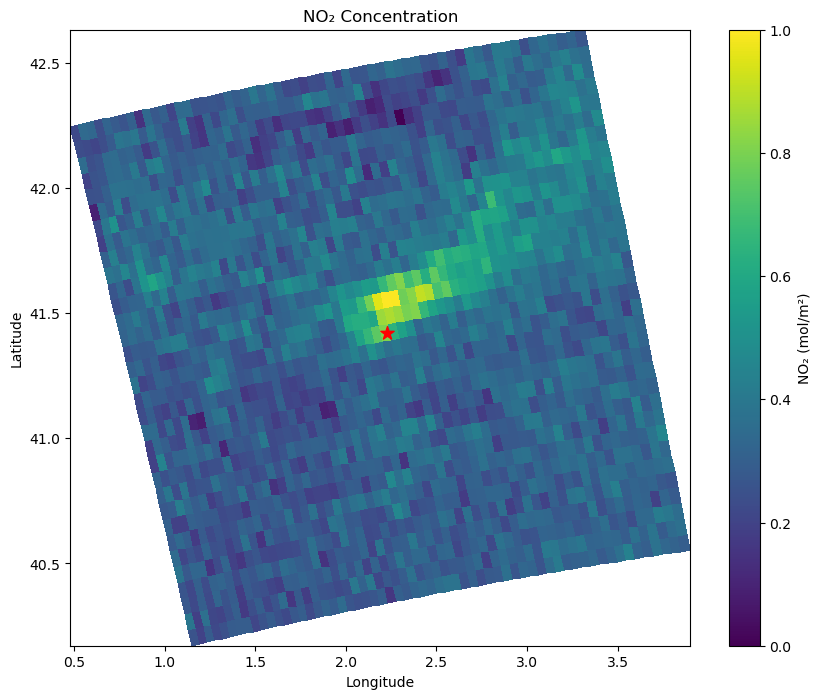

In [74]:
plt.figure(figsize=(10, 8))
plt.pcolormesh(zoomed_lons, zoomed_lats, zoomed_no2, shading='auto', cmap='viridis')
plt.scatter(plant_lon, plant_lat, color='red', marker='*', s=100, label='Power Plant')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('NO₂ Concentration')
plt.colorbar(label='NO₂ (mol/m²)')
plt.show()